#### Name: Ben Maxwell

# PHYS 230 Lab Assignment 13

### Monday, March 9, 2026: Chapter 6, sections 3.5 - 3.8
- Nonlinear equations - Newton's Method 

In [3]:
# put all import statements here
import numpy as np
import matplotlib.pyplot as plt

## Newton's Method - single variable (22 pts)

Solve the same problem from class used for binary search, but analyzed using Newton's Method instead. 
Find the roots of $$ f(x) = e^{x-\sqrt{x}}-x$$

To do this: 

1) Take the derivative by hand. You can use something like WolframAlpha to check your derivative. Write it in markdown. 

2) Write two functions - `f(x)` that returns the result of the function for a given $x$ value and `df(x)` one that returns the derivative. 

3) Make a plot of the function from $x=0$ to $x=5$. Use this to estimate the roots. 

4) Apply the functions to find both roots. 

*You must clearly comment your code and include a markdown cell explaining your process*

The derivative is: 

$$e^{x-\sqrt{x}}\left(1-\frac{1}{2\sqrt{x}}\right)-1 $$

# part 1
Use chain rule on e^(x-sqrt(x))
This gives 1-1/2sqrt(x) times e^(x-sqrt(x))
Then derivative of x is 1. 
Then the derivative is
$$e^{x-\sqrt{x}}\left(1-\frac{1}{2\sqrt{x}}\right)-1 $$

In [5]:
# part 2
#Defining f
def f(x):
    return np.exp(x-np.sqrt(x))-x

# Defining the derivative of f
def df(x):
    return np.exp(x-np.sqrt(x))*(1-1/(2*np.sqrt(x)))-1

For this I just wrote two user defined functions that return the values of the functions I define above. 

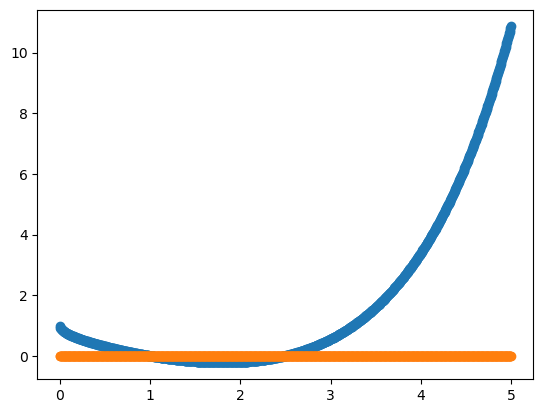

In [6]:
# part 3
#Creating the x values to use
x_vals = np.linspace(0, 5, 1000)
y_zero = np.zeros(1000)
#Plotting the function
plt.scatter(x_vals, f(x_vals))
plt.scatter(x_vals, y_zero)



To do this, I started by creating a list of 1000 values between 0 and 5 for the x values using a linspace. I then created an array of zeros to be my axis. Then, I just plotted the x_vals against the value of the function at each x_vals, and x_vals against the zeros as well. Based on my graph, my answers should be 1ish ad 2.5ish.

In [ ]:
# part 4

x_guess = np.array([1.,2.5])

#def variables
accuracy = 1e-10

#Apply newton's method
err = abs(-999.99)
#Going through is the accuracy wasn't good enough
while err > accuracy:
    delta  = f(x_guess)/df(x_guess) #Calculating the change
    x_guess -= delta #Updating the guess
    err = max(abs(delta)) #Updating the error

print(x_guess)


[1.         2.49090932]


To begin my code, I create an array of my guesses. Then, I set the accuracy to what I wasnt it to reach, which is to 1e-10 accuracy. Afterwards, I set the error to some random number thats above 1e-10. Then I went through a loop that continues when the err is bigger than the accuracy. For every value, the delta is found by finding f(x)/df(x). Then, the x_guesses are updated by the delta by subtracting it. Finally, I find the biggest error of the two guesses. Finally, I print my final answer. It seems my guesses were quite accurate

## Newton's Method - many variables (22 pts)
#### Adapted from Nonlinear Circuits (book exercise 6.18, pg. 276)

Exercise 6.1 used regular simultaneous equations to solve for the behavior of circuits of resistors.  Resistors are linear---current is proportional to voltage---and the resulting equations we need to solve are therefore also linear and can be solved by standard matrix methods.  Real circuits, however, often include nonlinear components.  To solve for the behavior of these circuits we need to solve nonlinear equations.

Consider the following simple circuit, a variation on the classic
Wheatstone bridge:

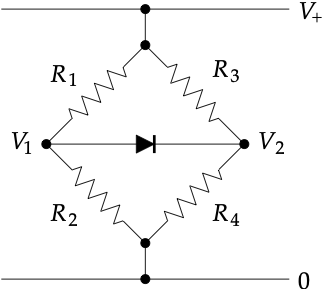

We will use Newton's Method to solve for the voltages in the 
The resistors obey the normal Ohm law, but the diode obeys the diode equation:
$$ I = I_0 (e^{V/V_T} - 1),$$
where $V$ is the voltage across the diode and $I_0$ and $V_T$ are constants.

The Kirchhoff current law says that the total net current flowing into or out of every point in a circuit must be zero.  Applying the law to voltage $V_1$ in the circuit above we get
$$
{V_1-V_+\over R_1} + {V_1\over R_2}
  + I_0\bigl[e^{(V_1-V_2)/V_T} - 1\bigr] = 0.
$$

   
1) In a markdown cell, derive the corresponding equation for voltage $V_2$.

2) Solve the two nonlinear equations for the voltages $V_1$ and $V_2$. 

3) Use Newton's method to solve the equations. This means you need to first take the derivatives of each equation with respect to each variable (so you'll have 4 equations). Define the Jacobian matrix. Setup the matrix necessary to analyze using the `np.linalg.solve()` function. Apply the following conditions: 

$$\begin{align*}
V_+ &= 5\,\textrm{V}, \\
R_1 &= 1\,\mathrm{k}\Omega, \qquad
R_2 = 4\,\mathrm{k}\Omega, \qquad
R_3 = 3\,\mathrm{k}\Omega, \qquad
R_4 = 2\,\mathrm{k}\Omega, \\
I_0 &= 3\,\textrm{nA},\qquad
V_T = 0.05\,\textrm{V}.
\end{align*}$$

4) Apply the function to find both roots to solve for $V_1$ and $V_2$. The electronic engineer's rule of thumb for diodes is that the voltage across a (forward biased) diode is always about 0.6 volts. Confirm that your results agree with this rule by taking the difference between your results.

*You must clearly comment your code and include a markdown cell explaining your process*

# part 1
Based on what I can tell, there is a 2 currents going in/out of V2. These currents plus the current at V2 is what you can find. The current at V2 can be found using the given equation as
$$I_0(e^{(V_1-V_2)/V_T}-1) $$
Then there is a current going from V2 with V2/R4 and V2-V+/R3. Putting this all together, I have the equation
$$ \frac{V_2-V_+}{R_3}+\frac{V_2}{R_4}-I_0(e^{(V_1-V_2)/V_T}-1) = 0$$

In [18]:
# part 3
#Defining all those constants
Vplus = 5. #V
R1 = 1000. #Ohm
R2 = 4000. #Ohm
R3 = 3000. #Ohm
R4 = 2000. #Ohm
I0 = 3e-9 #A
VT = 0.05 #V


#Defining the f.irst function
def f(V1,V2):
    return float((V1-Vplus)/R1 + (V1/R2) + I0*(np.exp((V1-V2)/VT)-1))
#Defining the second function
def g(V1,V2):
    return float((V2-Vplus)/R3 + (V2/R4) - I0*(np.exp((V1-V2)/VT)-1))

#Define variables
accuracy = 1e-10
#Initial guess
V1 = 1.
V2 = 1.
#Just making an error
err = abs(-999.99)

while err > accuracy:
    #Defining all the partial derivative
    a = (1/R1)+(1/R2)+(I0/VT)*np.exp((V1-V2)/VT)
    b = -(I0/VT)*np.exp((V1-V2)/VT)
    c = -(I0/VT)*np.exp((V1-V2)/VT)
    d = (1/R3)+(1/R4)+(I0/VT)*np.exp((V1-V2)/VT)
    #Making the jacobian matrix and other matrix needed to solve
    A = np.array([[a,b],
                  [c,d]], float)
    v = np.array([f(V1,V2), g(V1,V2)], float)
    #Solving
    values = np.linalg.solve(A,v)
    #Determine new values
    V1 -= values[0]
    V2 -= values[1]

    #Caclculate new error
    err = np.sqrt(values[0]**2+values[1]**2)


print(V1,V2)
print(abs(V2-V1))

3.4469546188585745 2.8295680717121385
0.6173865471464359


I did part 3 and 4 in the same place on accident I hope thats ok. I start my code by defining all the constants that were given. Then, I definied two functions, f(V1,V2) and g(V1,V2) which give back the two equations I derived earlier. Then, I set my accuracy to be within 1e-10. I guessed 1 for both V1 and V2. I also set the err is a very large value that is bigger than 1e-10. Then, I created a while loop to continue while err is bigger than my desired accuraccy. Then, I created the jacobian matrix of f and g, with my derivatives being defined seperately as a, b, c, and d because it was easier to see. I then also create a V array with f(v1, v2) and g(v1,v2). Then, I use the np.lingalg.solve for the values. I changed V1 and V2 by the new values given by the linalg.solve. Then, I calculated the error as the sqrt of the two values found from linalg. Finally, once everything is completed, I printed them. I also printed the difference, which was around 0.6. This is very excited as this was the difference I was meant to find. 